In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import pickle
import sys; sys.path.insert(0, '..')

from scipy.special import expit
from src.plot_function import plot_lifetime_avg, plot_pit_comp
from src.curve_calibration import find_delta

pd.options.display.float_format = '{:.3f}'.format
np.set_printoptions(suppress = True)
warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [3]:
# Constant parameters
WEIGHT_KEY = "n" #Define the key of weight in dictionary
PD_KEY = "Unbias" #Define the key of PD in dictionary
MODEL_NAME = "MODEL_1534" #Randomly selected
COHORT_LEVEL = "Yearly" #"Yearly" or "Monthly"

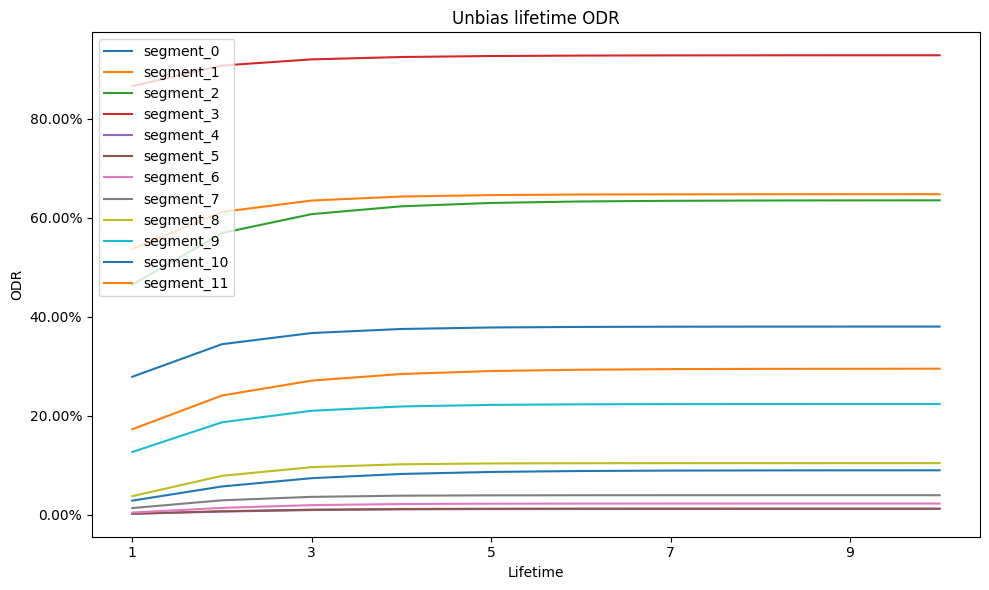

In [4]:
# Import unbias lifetime ODR
with open("../model/unbias_cumulative_odr.pkl", "rb") as f:
    unbias_lifetime = pickle.load(f)

# Dict for plot
unbias_curves = {
    k: v[PD_KEY]
    for k, v in unbias_lifetime.items()
}

# Show plot
plot_lifetime_avg(unbias_curves, "Unbias lifetime ODR")

In [5]:
# Import FWL Model
with open("../model/fwl_model.pkl", "rb") as f:
    model = pickle.load(f)

# Get model
model = model[MODEL_NAME]
final_vars = list(model.params[1:].index)
print(f"Final MEV(s): {final_vars}")

Final MEV(s): ['BROLP_MA9M_LAG9M', 'UNEM_MA9M_LAG3M', 'PIR_MA6M']


In [6]:
# Import MEV Data
mev_transformed = pd.read_parquet(
    '../data/processed/mev_transformed.parquet',
    engine = 'pyarrow'
)

# Select forecasting MEV(s)
mev_transformed = mev_transformed[final_vars].loc["2020-01-31":"2022-12-31"]
mev_transformed.insert(0, "const", 1) #Add constant

# Show table
mev_transformed.head(5)

,const,BROLP_MA9M_LAG9M,UNEM_MA9M_LAG3M,PIR_MA6M
Date,,,,
2020-01-31,1,68.344,0.978,1.375
2020-02-29,1,68.056,1.016,1.292
2020-03-31,1,66.327,1.022,1.167
2020-04-30,1,64.497,1.034,1.042
2020-05-31,1,63.839,1.032,0.917


In [7]:
# Prediction
pred = expit(model.predict(mev_transformed))
pred_yearly = np.array(pred.resample("YE").mean()) #To yearly basis
print("Forecasting PD")
for i, p in enumerate(pred_yearly):
    print(f"Year {i + 1}: {p * 100:.2f}%")

Forecasting PD
Year 1: 2.92%
Year 2: 1.45%
Year 3: 1.83%


In [8]:
# Lifetime PiT Calibration
pit_lifetime = find_delta(
    base_curve = unbias_lifetime,
    weight_key = WEIGHT_KEY,
    pd_key = PD_KEY,
    fwl_predict = pred_yearly,
    odr_level = COHORT_LEVEL    
)

=== Processing ===
[Delta optimization for lifetime PD]
=== Result ===
    Loss: 0.0
    Delta: [-0.09256549 -0.0600788  -0.05226838 -0.05087104 -0.06339015 -0.05240593
 -0.01810036 -0.0087022  -0.00269749 -0.0006173 ]


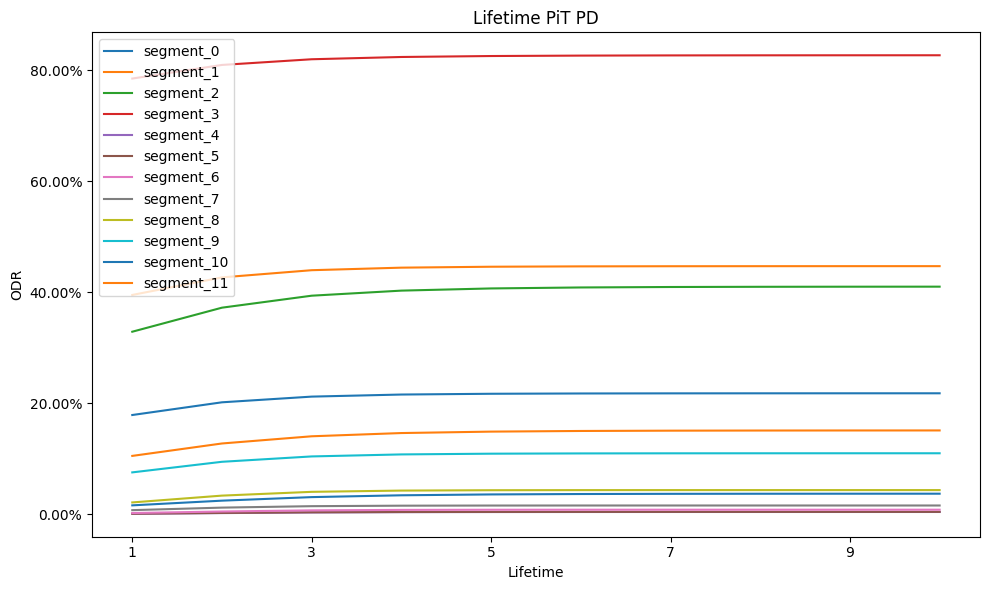

In [9]:
# Show plot
plot_lifetime_avg(pit_lifetime, "Lifetime PiT PD")

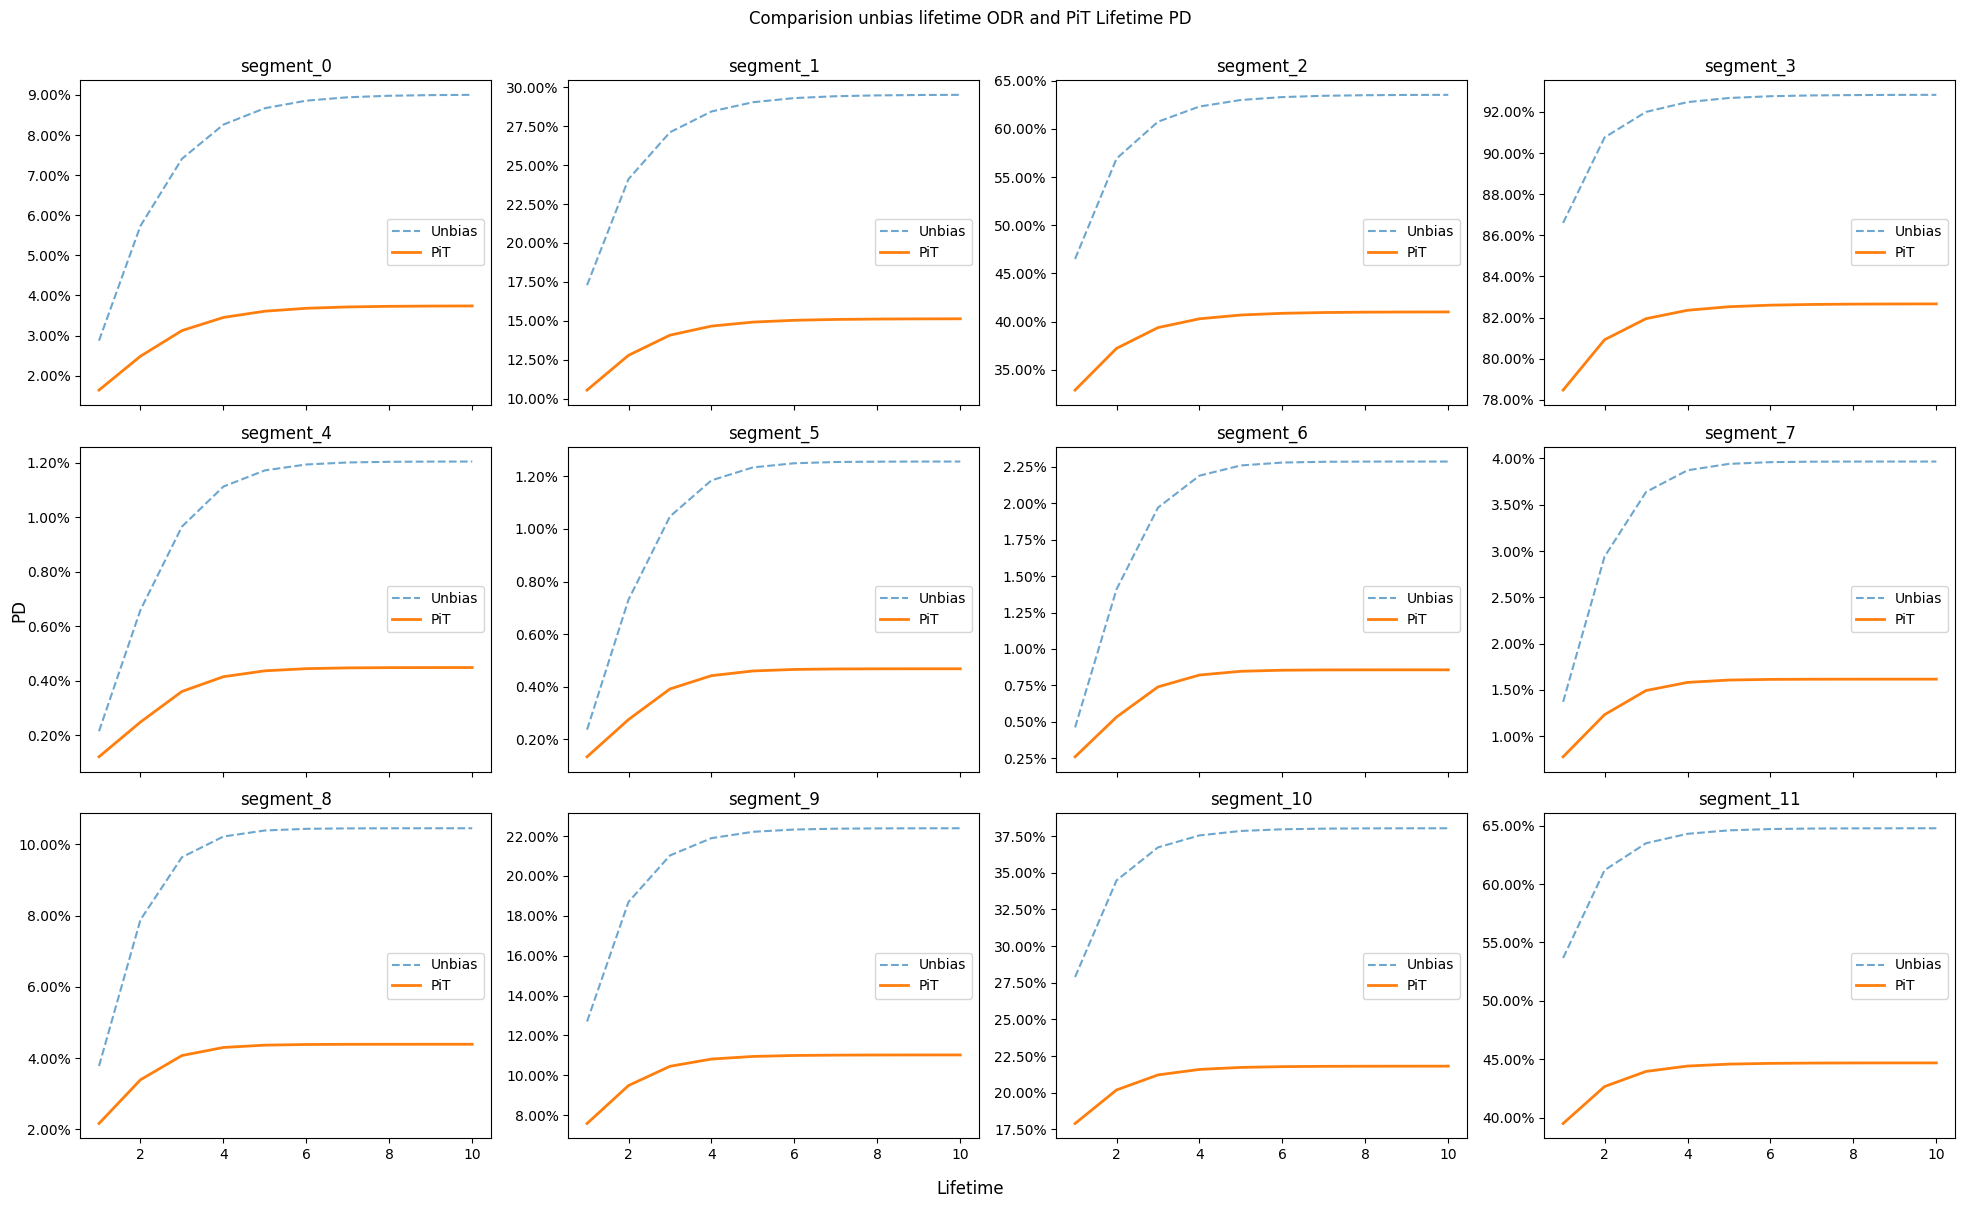

In [10]:
# Plot comparision unbias lifetime ODR and PiT Lifetime PD
plot_pit_comp(unbias_curves, pit_lifetime, "Comparision unbias lifetime ODR and PiT Lifetime PD")

In [11]:
# Save PiT Cumulative lifetime PD Result
with open('../model/pit_cumulative_lifetime_pd.pkl', 'wb') as f:
    pickle.dump(pit_lifetime, f)